# Part 1 — Step 1: Data Exploration

Before training any model, we verify the downloaded ACNE04 dataset is intact and understand its structure.

**This notebook:**
1. Summarises image and annotation counts per split
2. Shows the class distribution across all splits
3. Visualises sample images with ground-truth bounding boxes overlaid

**Run first:** `roboflow_loader.py --download` to populate `data/acne04/`

In [2]:
import json
import random
from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image, ImageDraw

%matplotlib inline

In [3]:
DATA_DIR = Path("../data/acne04")
OUT_DIR  = Path("../outputs/figures")
OUT_DIR.mkdir(parents=True, exist_ok=True)

SPLITS = ["train", "valid", "test"]

CLASS_COLORS = {
    "papules":                 "#00FFCE",
    "whitehead and blackhead": "#C7FC00",
    "pustules":                "#FE0056",
    "nodules and cysts":       "#8622FF",
}

## 1. Load annotations and print summary

In [4]:
def load_coco(split):
    path = DATA_DIR / split / "_annotations.coco.json"
    with open(path) as f:
        return json.load(f)

all_class_counts = Counter()

for split in SPLITS:
    coco = load_coco(split)
    id_to_name = {c["id"]: c["name"] for c in coco["categories"]}
    counts = Counter(id_to_name[a["category_id"]] for a in coco["annotations"])
    all_class_counts += counts

    print(f"[{split}]")
    print(f"  Images      : {len(coco['images'])}")
    print(f"  Annotations : {len(coco['annotations'])}")
    for cls, n in sorted(counts.items()):
        print(f"    {cls:<35} {n}")
    print()

print("[TOTAL across all splits]")
for cls, n in sorted(all_class_counts.items()):
    print(f"  {cls:<35} {n}")

[train]
  Images      : 991
  Annotations : 13389
    nodules and cysts                   5757
    papules                             3219
    pustules                            3738
    whitehead and blackhead             675

[valid]
  Images      : 283
  Annotations : 3425
    nodules and cysts                   1185
    papules                             914
    pustules                            1102
    whitehead and blackhead             224

[test]
  Images      : 142
  Annotations : 1737
    nodules and cysts                   733
    papules                             358
    pustules                            516
    whitehead and blackhead             130

[TOTAL across all splits]
  nodules and cysts                   7675
  papules                             4491
  pustules                            5356
  whitehead and blackhead             1029


## 2. Class distribution chart

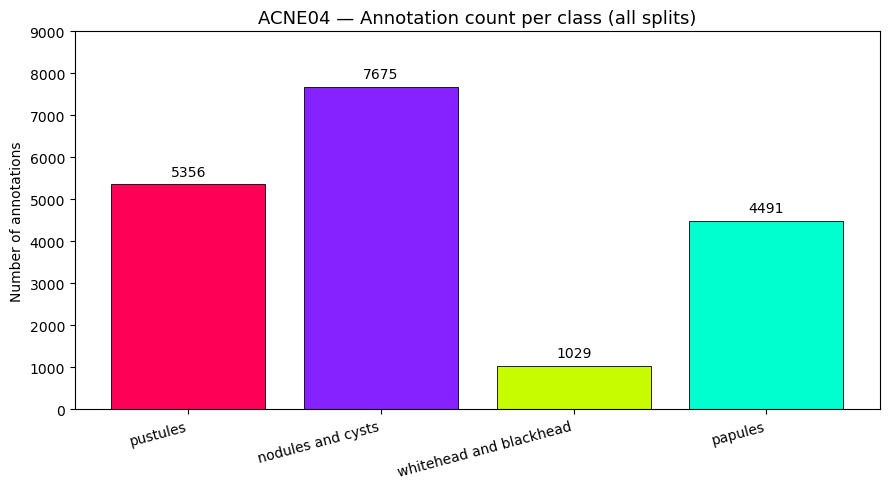

In [5]:
labels = list(all_class_counts.keys())
values = [all_class_counts[l] for l in labels]
colors = [CLASS_COLORS.get(l, "#888") for l in labels]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(labels, values, color=colors, edgecolor="black", linewidth=0.6)
ax.bar_label(bars, padding=4, fontsize=10)
ax.set_title("ACNE04 — Annotation count per class (all splits)", fontsize=13)
ax.set_ylabel("Number of annotations")
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=15, ha="right")
ax.set_ylim(0, 9000)
plt.tight_layout()
plt.savefig(OUT_DIR / "class_distribution.png", dpi=150)
plt.show()

## 3. Sample images with ground-truth bounding boxes

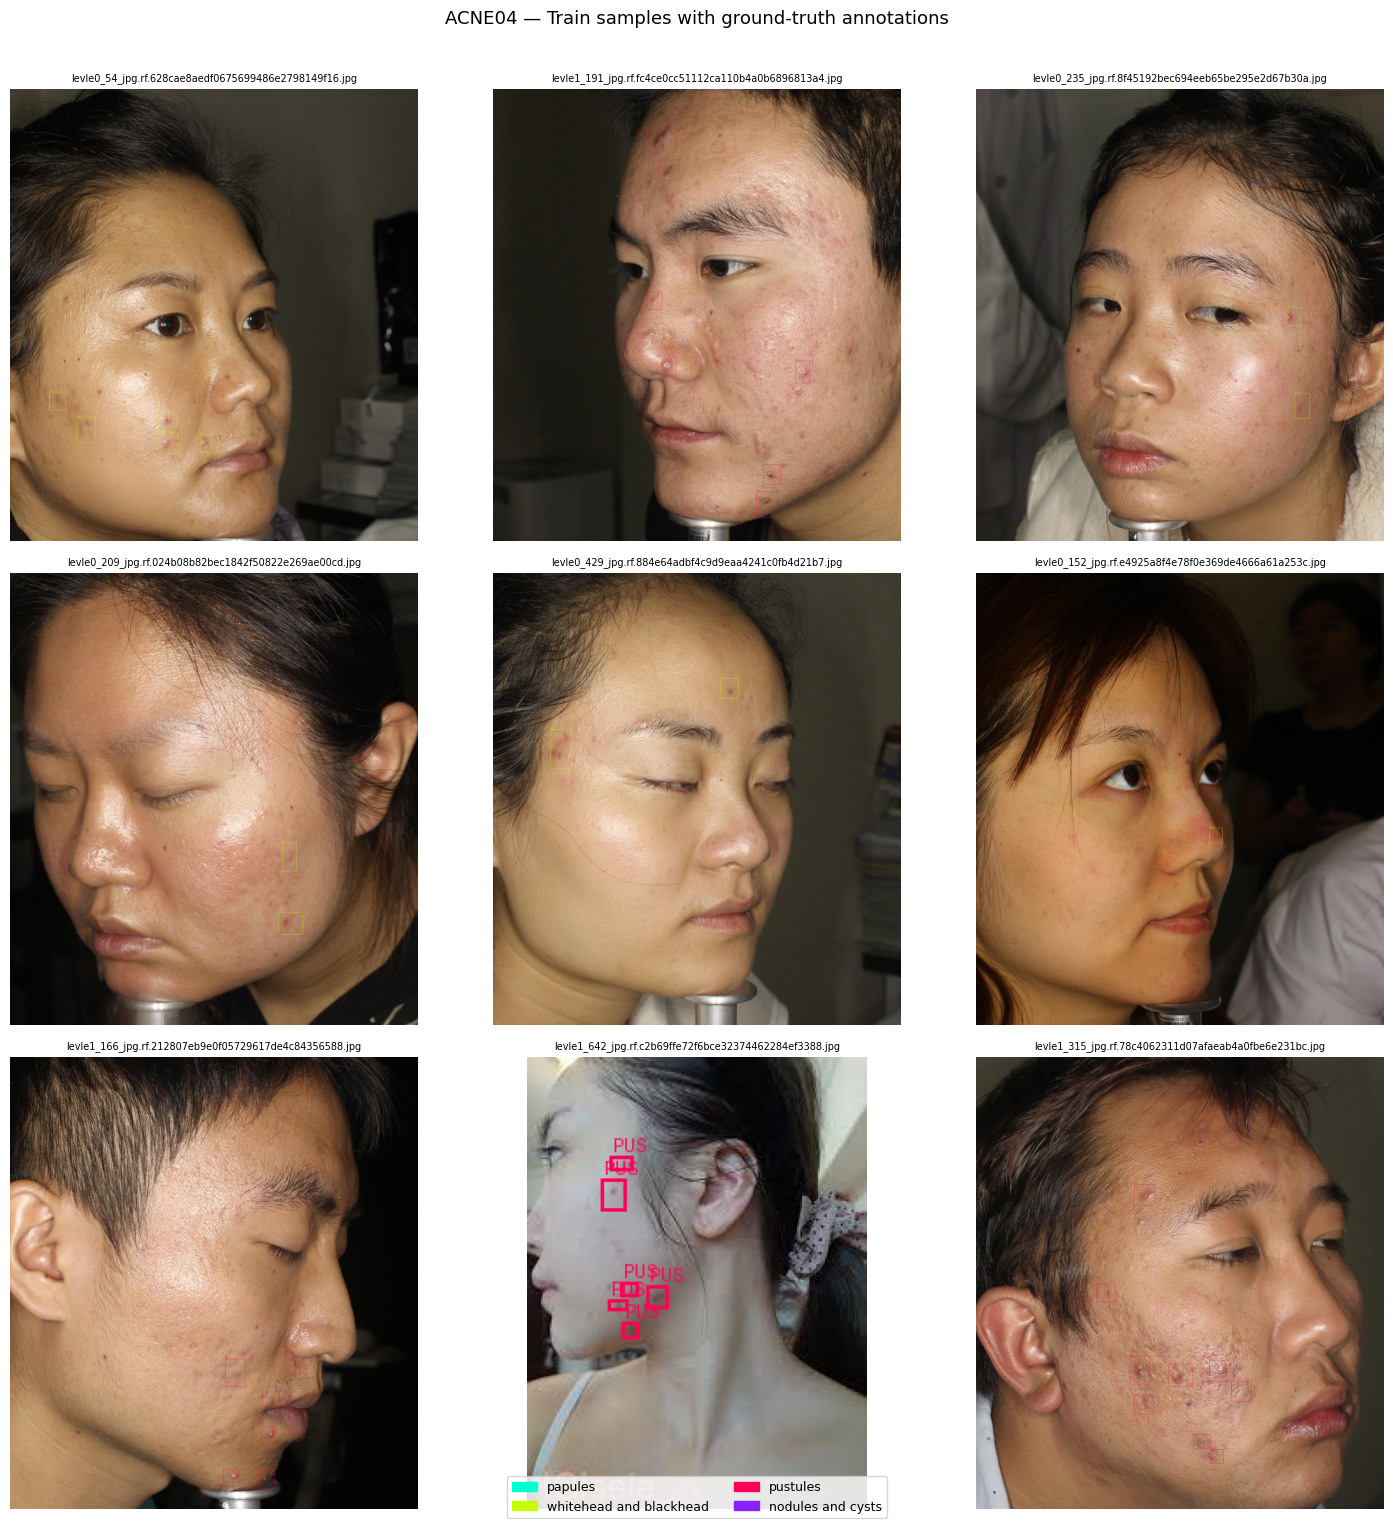

Saved → outputs/figures/sample_annotations.png


In [5]:
def draw_boxes(img, annotations, id_to_name):
    img = img.copy()
    draw = ImageDraw.Draw(img)
    for ann in annotations:
        x, y, w, h = ann["bbox"]
        label = id_to_name[ann["category_id"]]
        color = CLASS_COLORS.get(label, "#FFF")
        draw.rectangle([x, y, x+w, y+h], outline=color, width=2)
        draw.text((x+2, max(0, y-12)), label[:3].upper(), fill=color)
    return img

random.seed(42)
coco       = load_coco("train")
id_to_name = {c["id"]: c["name"] for c in coco["categories"]}
ann_map    = {}
for ann in coco["annotations"]:
    ann_map.setdefault(ann["image_id"], []).append(ann)

annotated = [img for img in coco["images"] if img["id"] in ann_map]
sample    = random.sample(annotated, min(9, len(annotated)))

fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

for i, meta in enumerate(sample):
    img  = Image.open(DATA_DIR / "train" / meta["file_name"]).convert("RGB")
    img  = draw_boxes(img, ann_map[meta["id"]], id_to_name)
    axes[i].imshow(img)
    axes[i].set_title(meta["file_name"], fontsize=7)
    axes[i].axis("off")

patches = [mpatches.Patch(color=c, label=l) for l, c in CLASS_COLORS.items()]
fig.legend(handles=patches, loc="lower center", ncol=2, fontsize=9, bbox_to_anchor=(0.5, 0))
plt.suptitle("ACNE04 — Train samples with ground-truth annotations", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / "sample_annotations.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → outputs/figures/sample_annotations.png")